# Mapillary Road Damage Screening (Polygon Output)

This notebook uses your Flask polygon extraction output (`*_network_edges.geojson`) and pulls nearby Mapillary images to flag **candidate** problem areas (screening only).

## What this does
- Loads polygon road edges from `outputs/`
- Samples points along each road edge
- Queries nearby Mapillary images
- Downloads image thumbnails
- Computes simple visual risk proxies (texture, dark patches, wet-looking patches)
- Aggregates image-level scores back to road edges

> Important: this is **not** a final pothole detector. It is a fast triage workflow to find likely hotspots for manual review or later model training.


True


In [12]:
import os
import requests

token = os.getenv("MAPILLARY_TOKEN", "").strip()

if not token:
    print("MAPILLARY_TOKEN is empty.")
else:
    print(f"Token loaded. Last 4 chars: {token[-4:]}")

    # Minimal API test
    url = "https://graph.mapillary.com/images"
    params = {
        "access_token": token,
        "fields": "id",
        "limit": 1
    }

    r = requests.get(url, params=params, timeout=20)
    print("HTTP status:", r.status_code)
    try:
        print("Response JSON:", r.json())
    except Exception:
        print("Raw response:", r.text[:500])


Token loaded. Last 4 chars: 6e75
HTTP status: 200
Response JSON: {'data': []}


In [13]:
from pathlib import Path
import os
import json
import time
import math
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from PIL import Image
from io import BytesIO

# -------- Paths / config --------
REPO_DIR = Path('/Users/miranda/Documents/GitHub/Sentinel-FYP')
OUTPUT_DIR = REPO_DIR / 'outputs'
EDGES_GEOJSON = OUTPUT_DIR / 'map2_extract_network_edges.geojson'   # change if needed
WORK_DIR = OUTPUT_DIR / 'mapillary_screen'
IMG_DIR = WORK_DIR / 'images'
WORK_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)

# Mapillary access token (set in terminal before launching notebook):
# export MAPILLARY_TOKEN='YOUR_TOKEN'
MAPILLARY_TOKEN = os.getenv('MAPILLARY_TOKEN', '').strip()

# Sampling + API controls
SAMPLE_STEP_M = 30     # point spacing along roads
SEARCH_RADIUS_M = 35   # mapillary image search radius
MAX_POINTS = 600       # hard cap for speed; increase if needed
REQUEST_SLEEP = 0.05   # polite delay between API calls

print('Edges file exists:', EDGES_GEOJSON.exists())
print('MAPILLARY_TOKEN set:', bool(MAPILLARY_TOKEN))

Edges file exists: True
MAPILLARY_TOKEN set: True


In [14]:
# Load road edges from polygon extraction
edges = gpd.read_file(EDGES_GEOJSON)
if edges.crs is None:
    edges = edges.set_crs('EPSG:4326')
else:
    edges = edges.to_crs('EPSG:4326')

# Keep valid line geometries only
edges = edges[edges.geometry.notna() & (~edges.geometry.is_empty)].copy()
edges = edges[edges.geometry.geom_type.isin(['LineString', 'MultiLineString'])].copy()

# stable edge id for aggregation
edges = edges.reset_index(drop=True)
edges['edge_id'] = edges.index.astype(int)

print('Road edges loaded:', len(edges))
edges.head(3)

Skipping field highway: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5


Road edges loaded: 13744


,u,v,key,osmid,oneway,reversed,length,bridge,junction,width,ref,access,geometry,edge_id
0,4823872509,325584123,0,514609165,False,False,76.32021300112599,nan,nan,nan,nan,nan,"LINESTRING (-0.27511 5.52774, -0.2758 5.52777)",0
1,325584123,4823872509,0,514609165,False,True,76.32021300112599,nan,nan,nan,nan,nan,"LINESTRING (-0.2758 5.52777, -0.27511 5.52774)",1
2,325584123,5529190054,0,634759692,False,False,58.36513621017393,nan,nan,nan,nan,nan,"LINESTRING (-0.2758 5.52777, -0.27575 5.52829)",2


In [ ]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import LineString, MultiLineString, Point

# edges_gdf should be your road edges GeoDataFrame (EPSG:4326)
# Example:
# edges_gdf = gpd.read_file("/Users/miranda/Documents/GitHub/Sentinel-FYP/outputs/map2_extract_network_edges.geojson").to_crs("EPSG:4326")

STEP_M = 30          # spacing along road
MAX_POINTS_PER_EDGE = 20

# metric CRS for spacing in meters
edges_m = edges.to_crs("EPSG:32630")  # Ghana mostly in UTM 30N
rows = []

def iter_lines(geom):
    if geom is None or geom.is_empty:
        return
    if isinstance(geom, LineString):
        yield geom
    elif isinstance(geom, MultiLineString):
        for g in geom.geoms:
            if g and not g.is_empty:
                yield g

for i, r in edges_m.iterrows():
    edge_id = r.get("edge_id", i)
    geom = r.geometry
    if geom is None or geom.is_empty:
        continue

    pts_on_edge = 0
    for ln in iter_lines(geom):
        L = ln.length
        if L <= 0:
            continue

        # sample interior points along the full road line
        d = STEP_M / 2.0
        while d < L and pts_on_edge < MAX_POINTS_PER_EDGE:
            p = ln.interpolate(d)
            rows.append({
                "edge_id": edge_id,
                "geometry": Point(p.x, p.y),
                "dist_m_along_edge": d
            })
            pts_on_edge += 1
            d += STEP_M

        if pts_on_edge >= MAX_POINTS_PER_EDGE:
            break

points_m = gpd.GeoDataFrame(rows, geometry="geometry", crs=edges_m.crs)
points = points_m.to_crs("EPSG:4326")

print("Sample points created:", len(points))
display(points.head())


Sample points created: 49813


,edge_id,geometry,dist_m_along_edge
0,0,POINT (-0.27525 5.52775),15.0
1,0,POINT (-0.27552 5.52776),45.0
2,0,POINT (-0.27579 5.52777),75.0
3,1,POINT (-0.27567 5.52777),15.0
4,1,POINT (-0.2754 5.52776),45.0


In [22]:
# Keep at most 5000 sampled points
MAX_N = 100

if len(points) > MAX_N:
    points = points.sample(n=MAX_N, random_state=42).reset_index(drop=True)
else:
    points = points.reset_index(drop=True)

print("Final sampled points:", len(points))
display(points.head())


Final sampled points: 100


,edge_id,geometry,dist_m_along_edge
0,419,POINT (-0.25358 5.53373),225.0
1,8470,POINT (-0.15679 5.55744),45.0
2,11461,POINT (-0.18508 5.57448),15.0
3,11629,POINT (-0.20462 5.57619),15.0
4,7332,POINT (-0.21302 5.5466),45.0


In [24]:
# Robust Mapillary query: bbox search + nearest-image selection
# Replaces closeto/radius logic

import time
import math
import requests
import pandas as pd

if not MAPILLARY_TOKEN:
    raise RuntimeError("MAPILLARY_TOKEN missing")

# --- sanity ---
print("points CRS:", points.crs)
if str(points.crs) != "EPSG:4326":
    raise ValueError(f"points must be EPSG:4326, got {points.crs}")

BASE = "https://graph.mapillary.com/images"
LIMIT_PER_QUERY = 50
SEARCH_RADIUS_M = 300   # 300m around each point (bbox half-size)
SLEEP = REQUEST_SLEEP if "REQUEST_SLEEP" in globals() else 0.05

def meters_to_deg_lat(m):
    return m / 111320.0

def meters_to_deg_lon(m, lat):
    return m / (111320.0 * math.cos(math.radians(lat)) + 1e-9)

def haversine_m(lon1, lat1, lon2, lat2):
    R = 6371000.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlmb = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dlmb/2)**2
    return 2*R*math.asin(math.sqrt(a))

rows = []

for _, r in points.iterrows():
    qlon, qlat = float(r.geometry.x), float(r.geometry.y)
    dlat = meters_to_deg_lat(SEARCH_RADIUS_M)
    dlon = meters_to_deg_lon(SEARCH_RADIUS_M, qlat)
    bbox = f"{qlon-dlon},{qlat-dlat},{qlon+dlon},{qlat+dlat}"

    rec = {
        "edge_id": int(r.edge_id),
        "query_lon": qlon,
        "query_lat": qlat,
        "status": None,
        "http_code": None,
        "error_msg": None,
        "used_radius_m": SEARCH_RADIUS_M,
        "image_id": None,
        "thumb_url": None,
        "captured_at": None,
        "img_lon": None,
        "img_lat": None,
        "nearest_dist_m": None,
    }

    params = {
        "access_token": MAPILLARY_TOKEN,
        "fields": "id,geometry,captured_at,thumb_1024_url,thumb_2048_url",
        "bbox": bbox,
        "limit": LIMIT_PER_QUERY,
    }

    try:
        resp = requests.get(BASE, params=params, timeout=30)
        rec["http_code"] = resp.status_code

        try:
            payload = resp.json()
        except Exception:
            rec["status"] = "bad_json"
            rec["error_msg"] = resp.text[:300]
            rows.append(rec)
            continue

        if resp.status_code != 200:
            rec["status"] = "http_error"
            rec["error_msg"] = str(payload)[:500]
            rows.append(rec)
            continue

        items = payload.get("data", [])
        if not items:
            rec["status"] = "no_image"
            rows.append(rec)
            continue

        # choose nearest image in bbox
        best = None
        best_d = 1e18
        for it in items:
            coords = (it.get("geometry") or {}).get("coordinates", [None, None])
            ilon, ilat = coords[0], coords[1]
            if ilon is None or ilat is None:
                continue
            d = haversine_m(qlon, qlat, float(ilon), float(ilat))
            if d < best_d:
                best_d = d
                best = it

        if best is None:
            rec["status"] = "no_geom"
            rows.append(rec)
            continue

        bcoords = (best.get("geometry") or {}).get("coordinates", [None, None])
        rec["status"] = "ok"
        rec["image_id"] = str(best.get("id")) if best.get("id") is not None else None
        rec["thumb_url"] = best.get("thumb_1024_url") or best.get("thumb_2048_url")
        rec["captured_at"] = best.get("captured_at")
        rec["img_lon"] = bcoords[0]
        rec["img_lat"] = bcoords[1]
        rec["nearest_dist_m"] = float(best_d)

        rows.append(rec)

    except Exception as e:
        rec["status"] = "exception"
        rec["error_msg"] = str(e)[:500]
        rows.append(rec)
    finally:
        time.sleep(SLEEP)

img_hits = pd.DataFrame(rows)
img_hits.to_csv(WORK_DIR / "mapillary_query_results_debug.csv", index=False)

print("Status counts:")
print(img_hits["status"].value_counts(dropna=False))
print("\nNearest distance summary (ok rows):")
if (img_hits["status"] == "ok").any():
    print(img_hits.loc[img_hits["status"] == "ok", "nearest_dist_m"].describe())
else:
    print("No ok rows")

display(img_hits.head(10))
display(img_hits[img_hits["status"] != "ok"][["status", "http_code", "error_msg"]].head(20))


points CRS: EPSG:4326
Status counts:
status
ok          77
no_image    23
Name: count, dtype: int64

Nearest distance summary (ok rows):
count     77.000000
mean     206.230661
std       98.023488
min        4.523044
25%      139.522591
50%      225.298459
75%      278.173192
max      373.900255
Name: nearest_dist_m, dtype: float64


,edge_id,query_lon,query_lat,status,http_code,error_msg,used_radius_m,image_id,thumb_url,captured_at,img_lon,img_lat,nearest_dist_m
0,419,-0.253582,5.533727,no_image,200,None,300,None,None,NaN,NaN,NaN,NaN
1,8470,-0.156792,5.557435,ok,200,None,300,311769408442150,https://scontent-mad1-1.xx.fbcdn.net/m1/v/t6/A...,1.701761e+12,-0.157147,5.559722,257.344169
2,11461,-0.185078,5.574484,ok,200,None,300,191553886162615,https://scontent-mad1-1.xx.fbcdn.net/m1/v/t6/A...,1.538674e+12,-0.186106,5.573592,150.924881
3,11629,-0.204616,5.576194,ok,200,None,300,1557597291510931,https://scontent-mad1-1.xx.fbcdn.net/m1/v/t6/A...,1.725820e+12,-0.206375,5.573726,336.373654
4,7332,-0.213024,5.546599,ok,200,None,300,477933690108961,https://scontent-mad1-1.xx.fbcdn.net/m1/v/t6/A...,1.566140e+12,-0.210878,5.546552,237.514604
5,8128,-0.177783,5.554145,ok,200,None,300,2756489574727078,https://scontent-mad1-1.xx.fbcdn.net/m1/v/t6/A...,1.767624e+12,-0.175803,5.553231,241.519369
6,6462,-0.238171,5.570216,no_image,200,None,300,None,None,NaN,NaN,NaN,NaN
7,5173,-0.239776,5.558018,ok,200,None,300,108892354615038,https://scontent-mad1-1.xx.fbcdn.net/m1/v/t6/A...,1.583667e+12,-0.240061,5.556767,142.548146
8,10807,-0.162153,5.571007,ok,200,None,300,124390427062897,https://scontent-mad1-1.xx.fbcdn.net/m1/v/t6/A...,1.659925e+12,-0.161249,5.571993,148.412645
9,10012,-0.165973,5.564532,ok,200,None,300,632273134837790,https://scontent-mad1-1.xx.fbcdn.net/m1/v/t6/A...,1.538146e+12,-0.167761,5.561843,358.513845


,status,http_code,error_msg
0,no_image,200,None
6,no_image,200,None
10,no_image,200,None
11,no_image,200,None
15,no_image,200,None
19,no_image,200,None
30,no_image,200,None
31,no_image,200,None
32,no_image,200,None
36,no_image,200,None


In [25]:
print("img_hits shape:", img_hits.shape)
print("img_hits columns:", img_hits.columns.tolist())
print(img_hits.head(5))
print(img_hits["status"].value_counts(dropna=False) if "status" in img_hits.columns else "no status col")


img_hits shape: (100, 13)
img_hits columns: ['edge_id', 'query_lon', 'query_lat', 'status', 'http_code', 'error_msg', 'used_radius_m', 'image_id', 'thumb_url', 'captured_at', 'img_lon', 'img_lat', 'nearest_dist_m']
   edge_id  query_lon  query_lat    status  http_code error_msg  \
0      419  -0.253582   5.533727  no_image        200      None   
1     8470  -0.156792   5.557435        ok        200      None   
2    11461  -0.185078   5.574484        ok        200      None   
3    11629  -0.204616   5.576194        ok        200      None   
4     7332  -0.213024   5.546599        ok        200      None   

   used_radius_m          image_id  \
0            300              None   
1            300   311769408442150   
2            300   191553886162615   
3            300  1557597291510931   
4            300   477933690108961   

                                           thumb_url   captured_at   img_lon  \
0                                               None           NaN       

In [26]:
# Keep successful unique images and download thumbnails (safe version)
required_cols = {"status", "image_id", "thumb_url"}
missing = required_cols - set(img_hits.columns)

if missing:
    print(f"Missing columns in img_hits: {missing}")
    print("Most likely cause: API query returned only errors (e.g., token/auth/field issue).")
    ok = pd.DataFrame(columns=["image_id", "thumb_url", "edge_id"])
else:
    ok = img_hits[img_hits["status"] == "ok"].copy()
    ok = ok.dropna(subset=["image_id", "thumb_url"]).drop_duplicates("image_id").copy()

print("Rows with usable images:", len(ok))

download_rows = []
for _, r in ok.iterrows():
    img_id = str(r.image_id)
    out = IMG_DIR / f"{img_id}.jpg"

    if not out.exists():
        try:
            rr = requests.get(r.thumb_url, timeout=20)
            rr.raise_for_status()
            out.write_bytes(rr.content)
            status = "downloaded"
        except Exception as e:
            status = f"error:{e}"
    else:
        status = "exists"

    download_rows.append({
        **r.to_dict(),
        "local_path": str(out),
        "dl_status": status,
    })

img_df = pd.DataFrame(download_rows)
img_df.to_csv(WORK_DIR / "mapillary_images_index.csv", index=False)

print("Downloaded/exists:", (img_df["dl_status"].isin(["downloaded", "exists"])).sum() if not img_df.empty else 0)
img_df.head(5)


Rows with usable images: 76
Downloaded/exists: 76


,edge_id,query_lon,query_lat,status,http_code,error_msg,used_radius_m,image_id,thumb_url,captured_at,img_lon,img_lat,nearest_dist_m,local_path,dl_status
0,8470,-0.156792,5.557435,ok,200,None,300,311769408442150,https://scontent-mad1-1.xx.fbcdn.net/m1/v/t6/A...,1.701761e+12,-0.157147,5.559722,257.344169,/Users/miranda/Documents/GitHub/Sentinel-FYP/o...,downloaded
1,11461,-0.185078,5.574484,ok,200,None,300,191553886162615,https://scontent-mad1-1.xx.fbcdn.net/m1/v/t6/A...,1.538674e+12,-0.186106,5.573592,150.924881,/Users/miranda/Documents/GitHub/Sentinel-FYP/o...,downloaded
2,11629,-0.204616,5.576194,ok,200,None,300,1557597291510931,https://scontent-mad1-1.xx.fbcdn.net/m1/v/t6/A...,1.725820e+12,-0.206375,5.573726,336.373654,/Users/miranda/Documents/GitHub/Sentinel-FYP/o...,downloaded
3,7332,-0.213024,5.546599,ok,200,None,300,477933690108961,https://scontent-mad1-1.xx.fbcdn.net/m1/v/t6/A...,1.566140e+12,-0.210878,5.546552,237.514604,/Users/miranda/Documents/GitHub/Sentinel-FYP/o...,downloaded
4,8128,-0.177783,5.554145,ok,200,None,300,2756489574727078,https://scontent-mad1-1.xx.fbcdn.net/m1/v/t6/A...,1.767624e+12,-0.175803,5.553231,241.519369,/Users/miranda/Documents/GitHub/Sentinel-FYP/o...,downloaded


In [27]:
# Simple image-risk scoring (screening proxy, not final detector)

def score_image(path):
    try:
        arr = np.array(Image.open(path).convert('RGB'), dtype=np.float32) / 255.0
    except Exception:
        return None

    # brightness and contrast structure
    gray = 0.299*arr[...,0] + 0.587*arr[...,1] + 0.114*arr[...,2]
    gx, gy = np.gradient(gray)
    grad = np.sqrt(gx*gx + gy*gy)

    # proxies
    texture = float(np.var(grad))  # roughness proxy
    dark_ratio = float((gray < 0.20).mean())

    # crude wet-like proxy: bright + low saturation + blue-ish tint
    mx = arr.max(axis=2)
    mn = arr.min(axis=2)
    sat = np.where(mx > 1e-6, (mx - mn) / mx, 0.0)
    wet_like = ((mx > 0.35) & (sat < 0.20) & (arr[...,2] >= arr[...,1]) & (arr[...,2] >= arr[...,0]))
    wet_ratio = float(wet_like.mean())

    # combined risk score
    risk = 0.50*texture + 0.30*dark_ratio + 0.20*wet_ratio

    return {
        'texture_var': texture,
        'dark_ratio': dark_ratio,
        'wet_ratio': wet_ratio,
        'risk_score': risk,
    }

usable = img_df[img_df['dl_status'].isin(['downloaded', 'exists'])].copy()
scored = []
for _, r in usable.iterrows():
    s = score_image(r.local_path)
    if s is None:
        continue
    scored.append({**r.to_dict(), **s})

score_df = pd.DataFrame(scored)
if score_df.empty:
    raise RuntimeError('No images scored. Check download/API cells.')

# normalize risk 0..1 for readability
mn, mx = score_df['risk_score'].min(), score_df['risk_score'].max()
if mx > mn:
    score_df['risk_norm'] = (score_df['risk_score'] - mn) / (mx - mn)
else:
    score_df['risk_norm'] = 0.0

score_df.to_csv(WORK_DIR / 'mapillary_image_scores.csv', index=False)
score_df[['image_id','edge_id','risk_norm','texture_var','dark_ratio','wet_ratio']].head()

/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_58516/3097173926.py:21: RuntimeWarning: invalid value encountered in divide
  sat = np.where(mx > 1e-6, (mx - mn) / mx, 0.0)


,image_id,edge_id,risk_norm,texture_var,dark_ratio,wet_ratio
0,311769408442150,8470,0.246642,0.001289,0.120059,0.163284
1,191553886162615,11461,0.905868,0.002635,0.479285,0.357493
2,1557597291510931,11629,0.467163,0.000744,0.198493,0.293338
3,477933690108961,7332,0.217216,0.002606,0.135511,0.103942
4,2756489574727078,8128,0.132155,0.001193,0.052143,0.137505


In [28]:
# Aggregate image scores back to road edges
edge_scores = (
    score_df.groupby('edge_id')
    .agg(
        n_images=('image_id', 'nunique'),
        risk_mean=('risk_norm', 'mean'),
        risk_max=('risk_norm', 'max'),
        wet_mean=('wet_ratio', 'mean'),
        dark_mean=('dark_ratio', 'mean'),
    )
    .reset_index()
)

edges_scored = edges.merge(edge_scores, on='edge_id', how='left')
edges_scored['n_images'] = edges_scored['n_images'].fillna(0)
edges_scored['risk_mean'] = edges_scored['risk_mean'].fillna(0)
edges_scored['risk_max'] = edges_scored['risk_max'].fillna(0)

# Top candidate hotspot segments
hotspots = edges_scored.sort_values(['risk_max','risk_mean'], ascending=False).head(30).copy()

print('Edges with at least one image:', int((edges_scored['n_images'] > 0).sum()))
print('Top hotspots:', len(hotspots))
hotspots[['edge_id','n_images','risk_mean','risk_max']].head(10)

Edges with at least one image: 75
Top hotspots: 30


,edge_id,n_images,risk_mean,risk_max
13326,13326,1.0,1.000000,1.000000
11461,11461,1.0,0.905868,0.905868
10670,10670,1.0,0.876598,0.876598
8646,8646,1.0,0.838686,0.838686
10188,10188,1.0,0.700204,0.700204
11800,11800,1.0,0.668888,0.668888
5805,5805,1.0,0.653537,0.653537
5753,5753,1.0,0.617543,0.617543
12507,12507,1.0,0.593128,0.593128
12846,12846,1.0,0.593091,0.593091


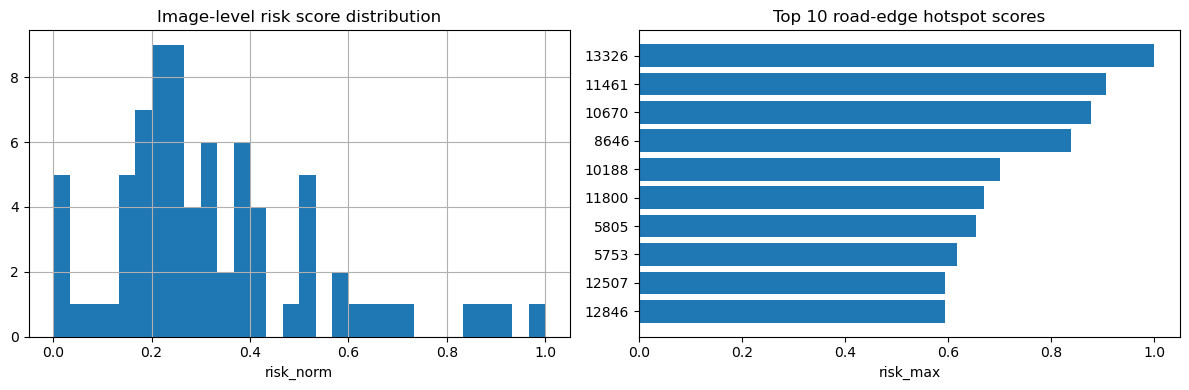

In [29]:
# Quick plots
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

score_df['risk_norm'].hist(bins=30, ax=ax[0])
ax[0].set_title('Image-level risk score distribution')
ax[0].set_xlabel('risk_norm')

top10 = hotspots[['edge_id','risk_max']].head(10).iloc[::-1]
ax[1].barh(top10['edge_id'].astype(str), top10['risk_max'])
ax[1].set_title('Top 10 road-edge hotspot scores')
ax[1].set_xlabel('risk_max')

plt.tight_layout()
plt.show()

In [ ]:
# Save outputs for your Flask app / further review
edges_out = WORK_DIR / 'polygon_edges_mapillary_scored.geojson'
hotspots_out = WORK_DIR / 'polygon_hotspots_top30.geojson'

edges_scored.to_file(edges_out, driver='GeoJSON')
hotspots.to_file(hotspots_out, driver='GeoJSON')

summary = {
    'n_edges_total': int(len(edges_scored)),
    'n_edges_with_images': int((edges_scored['n_images'] > 0).sum()),
    'n_images_scored': int(len(score_df)),
    'top_hotspot_edge_id': int(hotspots.iloc[0]['edge_id']) if len(hotspots) else None,
    'outputs': {
        'edges_scored_geojson': str(edges_out),
        'hotspots_geojson': str(hotspots_out),
        'image_scores_csv': str(WORK_DIR / 'mapillary_image_scores.csv'),
    }
}

with open(WORK_DIR / 'mapillary_screening_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

summary